In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
fnames = ["results.npy", "results_fine.npy", "results_fine2.npy"]

results8 = np.concatenate([np.load(f"forAlberto/N=8/{fname}") for fname in fnames], axis=1)
results16 = np.concatenate([np.load(f"forAlberto/N=16/{fname}") for fname in fnames], axis=1)
results32 = np.concatenate([np.load(f"forAlberto/N=32/{fname}") for fname in fnames], axis=1)

results8.shape

(14, 36, 3, 2)

Best N=8 C: [1.52 1.53 1.5  1.51 1.49 1.44 1.47 1.48 1.6  1.46 1.45 1.43 1.5  1.7
 1.42 1.58 1.41 1.55 1.61 1.6  1.54 1.57 1.54 1.56 1.59 1.62 1.4  1.39
 1.4  1.38 1.8  1.9  1.3  1.2  1.1  1.  ]
Best N=16 C: [1.53 1.58 1.52 1.59 1.57 1.56 1.6  1.61 1.55 1.54 1.51 1.62 1.5  1.54
 1.49 1.6  1.48 1.47 1.7  1.5  1.46 1.45 1.44 1.8  1.43 1.42 1.41 1.4
 1.4  1.39 1.9  1.38 1.3  1.2  1.1  1.  ]
Best N=32 C: [1.54 1.53 1.52 1.51 1.54 1.5  1.55 1.5  1.49 1.56 1.48 1.57 1.58 1.47
 1.59 1.46 1.6  1.6  1.45 1.61 1.44 1.62 1.43 1.42 1.41 1.4  1.4  1.39
 1.38 1.7  1.8  1.3  1.9  1.2  1.1  1.  ]


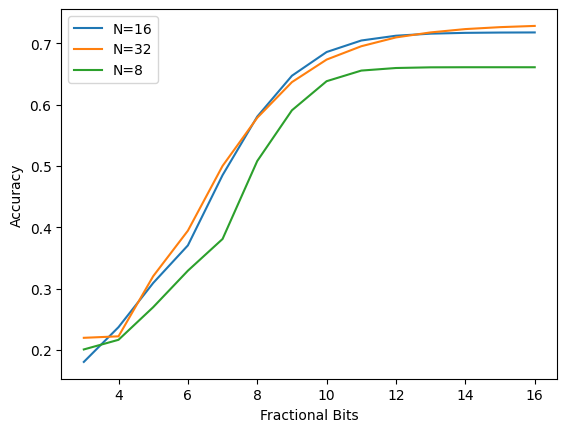

In [17]:
FRAC_BITS = np.arange(3, 17)
CS = np.concatenate([np.arange(1, 2, 0.1), np.arange(1.38, 1.54, 0.01), np.arange(1.54, 1.63, 0.01)])

bestidx_8 = results8[..., 1].mean(axis=2)[-4:].sum(axis=0).argsort()[::-1]
bestidx_16 = results16[..., 1].mean(axis=2)[-4:].sum(axis=0).argsort()[::-1]
bestidx_32 = results32[..., 1].mean(axis=2)[-4:].sum(axis=0).argsort()[::-1]

print("Best N=8 C:", CS[bestidx_8])
print("Best N=16 C:", CS[bestidx_16])
print("Best N=32 C:", CS[bestidx_32])

plt.plot(FRAC_BITS, results16.mean(axis=2)[:, bestidx_16[0], 1], label="N=16")
plt.plot(FRAC_BITS, results32.mean(axis=2)[:, bestidx_16[0], 1], label="N=32")
plt.plot(FRAC_BITS, results8.mean(axis=2)[:, bestidx_16[0], 1], label="N=8")
plt.xlabel("Fractional Bits")
plt.ylabel("Accuracy")
plt.legend()

In [18]:
idx = bestidx_16[0]
idx

np.int64(25)

In [19]:
np.save("forAlberto/N=8/best_results8.npy", results8[:, idx, : ,:])
np.save("forAlberto/N=16/best_results16.npy", results16[:, idx, : ,:])
np.save("forAlberto/N=32/best_results32.npy", results32[:, idx, : ,:])